In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import time
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchinfo
import torch.amp as amp

from Generator import noise_mul
from Model import EdgePreservingDenoiser, SyntheticNoiseDataset, evaluate_model
from Helper import load_checkpoint_generic, save_checkpoint_generic

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


In [2]:
# =============================================================================
# DEVICE SETUP
# =============================================================================
print("=" * 80)
print("DEVICE CONFIGURATION")
print("=" * 80)

if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    print(f"✅ CUDA available with {num_devices} device(s)")

    for i in range(num_devices):
        device_name = torch.cuda.get_device_name(i)
        total_memory = torch.cuda.get_device_properties(i).total_memory / 1e9  # in GB
        print(f"   Device {i}: {device_name} ({total_memory:.2f} GB)")
else:
    print("⚠️  CUDA not available, using CPU")

print("=" * 80)
print()

DEVICE CONFIGURATION
✅ CUDA available with 1 device(s)
   Device 0: NVIDIA GeForce RTX 3070 (8.59 GB)



In [3]:
# =============================================================================
# HYPERPARAMETERS
# =============================================================================
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
MAX_ITERATIONS = 100_000  # Total training iterations
VALIDATION_INTERVAL = 100  # Validate every N iterations
CHECKPOINT_INTERVAL = 1000  # Save checkpoint every N iterations
LOG_INTERVAL = 20  # Log training progress every N iterations

# Dataset Configuration
TRAIN_SIZE = 5000  # Number of training samples
VAL_SIZE = 500     # Number of validation samples

# Noise Configuration
# NOISE_FN = noise_add  # Additive noise
NOISE_FN = noise_mul   # Multiplicative noise
NOISE_RANGE = (0.1, 0.3)

# Loss Configuration
LOSS_FN = 'MSE'  # Options: MSE, RMSE, MAE

# Checkpoint directory
CHECKPOINT_DIR = f"checkpoints-{NOISE_FN.__name__}"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


In [4]:
# =============================================================================
# DATASET UTILITIES
# =============================================================================
from pathlib import Path
import pickle


def load_dataset_arrays(checkpoint_dir, dataset_name):
    """
    Naloži dataset arrays iz pickle file.

    Args:
        checkpoint_dir: Direktorij s checkpointi
        dataset_name: Ime dataseta ('train' ali 'val')

    Returns:
        (clean_images, noisy_images) ali (None, None) če ne obstaja
    """
    checkpoint_dir = Path(checkpoint_dir)
    dataset_path = checkpoint_dir / f"{dataset_name}_dataset.pkl"

    if dataset_path.exists():
        print(f"📂 Loading {dataset_name} dataset from {dataset_path}")
        with open(dataset_path, 'rb') as f:
            data = pickle.load(f)

        clean_images = data['clean']
        noisy_images = data['noisy']
        print(f"✅ Loaded {len(clean_images)} samples")
        return clean_images, noisy_images
    else:
        print(f"⚠️ No {dataset_name} dataset found at {dataset_path}")
        return None, None


def save_dataset_arrays(checkpoint_dir, dataset_name, dataset, overwrite=False):
    """
    Save dataset tensors to `checkpoint_dir/{dataset_name}_dataset.pkl`.
    Accepts `dataset.clean`/`dataset.noisy` as either:
      - a stacked torch.Tensor shape [N, C, H, W], or
      - an iterable/list of per-sample tensors/arrays.
    """
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(exist_ok=True)
    dataset_path = checkpoint_dir / f"{dataset_name}_dataset.pkl"

    if dataset_path.exists() and not overwrite:
        print(f"⚠️ Dataset already exists at {dataset_path}. Set overwrite=True to replace.")
        return

    def _ensure_stacked(tensors):
        # If already a tensor, use it; otherwise try to stack an iterable
        if isinstance(tensors, torch.Tensor):
            t = tensors
        else:
            t = torch.stack(list(tensors), dim=0)
        # detach, move to cpu and make contiguous for safe pickling
        return t.detach().cpu().contiguous()

    clean_t = _ensure_stacked(dataset.clean)
    noisy_t = _ensure_stacked(dataset.noisy)

    data = {
        'clean': clean_t,
        'noisy': noisy_t
    }

    print(f"💾 Saving {dataset_name} dataset to {dataset_path}")
    with open(dataset_path, 'wb') as f:
        pickle.dump(data, f)

    print(f"✅ Saved {clean_t.shape[0]} samples")

In [5]:
# =============================================================================
# MODEL SETUP & DATA LOADING
# =============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 80)
print(f"TRAINING DEVICE: {device}")
print("=" * 80)
print()

# Model
model = EdgePreservingDenoiser().to(device)
if device.type == 'cuda':
    model.to(memory_format=torch.channels_last)

# === LOAD OR GENERATE TRAIN DATASET ===
print("=" * 80)
print("DATASET PREPARATION")
print("=" * 80)
train_clean, train_noisy = load_dataset_arrays(CHECKPOINT_DIR, "train")

if train_clean is not None:
    # Podatki obstajajo - uporabi jih (že v CHW formatu)
    train_dataset = SyntheticNoiseDataset(
        clean_images=train_clean,
        noisy_images=train_noisy,
        to_channels_last=True,
    )
    print(f"✅ Train dataset created from loaded data: {len(train_dataset)} samples")
else:
    # Podatki ne obstajajo - generiraj nove
    print(f"🎨 Generating train dataset ({TRAIN_SIZE} samples)...")
    train_dataset = SyntheticNoiseDataset(
        num_samples=TRAIN_SIZE,
        noise_fn=NOISE_FN,
        noise_range=NOISE_RANGE,
        to_channels_last=True,
    )
    # Shrani dataset direktno (že v CHW formatu)
    save_dataset_arrays(CHECKPOINT_DIR, "train", train_dataset)
    print(f"✅ Train dataset generated and saved: {len(train_dataset)} samples")

# === LOAD OR GENERATE VALIDATION DATASET ===
val_clean, val_noisy = load_dataset_arrays(CHECKPOINT_DIR, "val")

if val_clean is not None:
    # Podatki obstajajo - uporabi jih (že v CHW formatu)
    val_dataset = SyntheticNoiseDataset(
        clean_images=val_clean,
        noisy_images=val_noisy,
        to_channels_last=True,
    )
    print(f"✅ Validation dataset created from loaded data: {len(val_dataset)} samples")
else:
    # Podatki ne obstajajo - generiraj nove
    print(f"🎨 Generating validation dataset ({VAL_SIZE} samples)...")
    val_dataset = SyntheticNoiseDataset(
        num_samples=VAL_SIZE,
        noise_fn=NOISE_FN,
        noise_range=NOISE_RANGE,
        to_channels_last=True,
    )
    # Shrani dataset direktno (že v CHW formatu)
    save_dataset_arrays(CHECKPOINT_DIR, "val", val_dataset)
    print(f"✅ Validation dataset generated and saved: {len(val_dataset)} samples")

torch.backends.cudnn.benchmark = True

# === CREATE DATALOADERS ===
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

print("=" * 80)
print()


TRAINING DEVICE: cuda

DATASET PREPARATION
⚠️ No train dataset found at checkpoints-noise_mul\train_dataset.pkl
🎨 Generating train dataset (5000 samples)...
💾 Saving train dataset to checkpoints-noise_mul\train_dataset.pkl
✅ Saved 5000 samples
✅ Train dataset generated and saved: 5000 samples
⚠️ No val dataset found at checkpoints-noise_mul\val_dataset.pkl
🎨 Generating validation dataset (500 samples)...
💾 Saving val dataset to checkpoints-noise_mul\val_dataset.pkl
✅ Saved 500 samples
✅ Validation dataset generated and saved: 500 samples



In [6]:
# =============================================================================
# OPTIMIZER & LOSS FUNCTION
# =============================================================================
# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scaler = amp.GradScaler()


# Loss function
if LOSS_FN == 'MSE':
    criterion = nn.MSELoss()
elif LOSS_FN == 'RMSE':
    criterion = lambda pred, target: torch.sqrt(nn.MSELoss()(pred, target))
elif LOSS_FN == 'MAE':
    criterion = nn.L1Loss()
else:
    raise ValueError(f"Unknown loss function: {LOSS_FN}")

print("=" * 80)
print("OPTIMIZER & LOSS")
print("=" * 80)
print(f"Optimizer:      AdamW")
print(f"Learning Rate:  {LEARNING_RATE}")
print(f"Loss Function:  {LOSS_FN}")
print("=" * 80)
print()

OPTIMIZER & LOSS
Optimizer:      AdamW
Learning Rate:  0.001
Loss Function:  MSE



In [7]:
# =============================================================================
# MODEL ARCHITECTURE SUMMARY
# =============================================================================
torchinfo.summary(model, input_size=(1, 3, 256, 256), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
EdgePreservingDenoiser                   [1, 3, 256, 256]          --
├─FilterBranch: 1-1                      [1, 3, 8, 256, 256]       --
│    └─Conv2d: 2-1                       [1, 8, 256, 256]          976
│    └─Conv2d: 2-2                       [1, 8, 256, 256]          976
│    └─Conv2d: 2-3                       [1, 8, 256, 256]          976
├─WeightBranch: 1-2                      [1, 8, 256, 256]          --
│    └─ResNetBlock: 2-4                  [1, 32, 256, 256]         --
│    │    └─Conv2d: 3-1                  [1, 32, 256, 256]         128
│    │    └─Conv2d: 3-2                  [1, 32, 256, 256]         896
│    │    └─Dropout2d: 3-3               [1, 32, 256, 256]         --
│    │    └─ReLU: 3-4                    [1, 32, 256, 256]         --
│    │    └─Conv2d: 3-5                  [1, 32, 256, 256]         9,248
│    │    └─Dropout2d: 3-6               [1, 32, 256, 256]         --
│    │ 

In [8]:
# =============================================================================
# TRAINING LOOP
# =============================================================================
# Load checkpoint
checkpoint = load_checkpoint_generic(CHECKPOINT_DIR, device=device)

start_iteration = 1
train_losses = []
val_losses = []
val_snrs = []
val_psnrs = []
best_val_loss = float('inf')  # Track best validation loss

if checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_iteration = checkpoint.get('iteration', 0) + 1
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    val_snrs = checkpoint.get('val_snrs', [])
    val_psnrs = checkpoint.get('val_psnrs', [])
    best_val_loss = checkpoint.get('best_val_loss', min(val_losses) if val_losses else float('inf'))

    print("=" * 80)
    print("CHECKPOINT LOADED")
    print("=" * 80)
    print(f"Resuming from iteration:    {start_iteration}")
    print(f"Train losses recorded:      {len(train_losses)}")
    print(f"Val losses recorded:        {len(val_losses)}")
    if val_losses:
        print(f"Best Val Loss so far:       {best_val_loss:.6f}")
    if val_psnrs:
        print(f"Best Val PSNR so far:       {max(val_psnrs):.2f} dB")
    print("=" * 80)
    print()
else:
    print("=" * 80)
    print("STARTING NEW TRAINING")
    print("=" * 80)
    print()

model.train()

# Iterator for infinite iteration through dataset
train_iterator = iter(train_loader)

print("=" * 80)
print("TRAINING STARTED")
print("=" * 80)
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)
print()

training_start_time = time.time()
last_log_time = time.time()

for iteration in range(start_iteration, MAX_ITERATIONS + 1):
    try:
        noisy, clean = next(train_iterator)
    except StopIteration:
        # Restart iterator when we reach the end of dataset
        train_iterator = iter(train_loader)
        noisy, clean = next(train_iterator)

    noisy = noisy.to(device, non_blocking=True)
    clean = clean.to(device, non_blocking=True)

    # Forward pass
    optimizer.zero_grad(set_to_none=True)
    with amp.autocast(device_type=device.type):
        denoised = model(noisy)
        loss = criterion(denoised, clean)

    # Backward pass
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # Track metrics
    train_losses.append(loss.item())

    # === CONSOLE LOGGING ===
    if iteration % LOG_INTERVAL == 0 or iteration == 1 or iteration == MAX_ITERATIONS:
        current_time = time.time()
        interval_time = current_time - last_log_time

        # Fix: Calculate actual iterations in this interval
        if iteration == 1:
            actual_iters = 1
        elif iteration == MAX_ITERATIONS and iteration % LOG_INTERVAL != 0:
            actual_iters = iteration % LOG_INTERVAL
        else:
            actual_iters = LOG_INTERVAL

        avg_iter_time = interval_time / actual_iters
        last_log_time = current_time

        remaining_iters = MAX_ITERATIONS - iteration
        eta_seconds = remaining_iters * avg_iter_time
        eta_hours = eta_seconds / 3600

        # Recent average loss (smooth over last LOG_INTERVAL iterations)
        recent_losses = train_losses[-LOG_INTERVAL:] if len(train_losses) >= LOG_INTERVAL else train_losses
        avg_loss = np.mean(recent_losses)

        # Progress percentage
        progress = (iteration / MAX_ITERATIONS) * 100

        print(f"[Iter {iteration:6d}/{MAX_ITERATIONS}] "
              f"Loss: {loss.item():.6f} (avg: {avg_loss:.6f}) | "
              f"Interval: {interval_time:.2f}s ({avg_iter_time:.3f}s/iter) | "
              f"ETA: {eta_hours:.2f}h | "
              f"Progress: {progress:.1f}%")

    # === VALIDATION ===
    if iteration % VALIDATION_INTERVAL == 0:
        val_start = time.time()
        val_loss, val_snr, val_psnr = evaluate_model(model, val_loader, device)
        val_time = time.time() - val_start

        val_losses.append(val_loss)
        val_snrs.append(val_snr)
        val_psnrs.append(val_psnr)

        # Check if this is the best model based on validation loss
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss

        # Compact one-line validation output
        best_indicator = " 🌟 BEST!" if is_best else ""
        print(f"[VAL @ {iteration:6d}] Loss: {val_loss:.6f}{best_indicator} | "
              f"SNR: {val_snr:.2f} dB | PSNR: {val_psnr:.2f} dB | "
              f"Time: {val_time:.2f}s")

        model.train()  # Back to training mode

    # === CHECKPOINT SAVING ===
    if iteration % CHECKPOINT_INTERVAL == 0 or iteration == MAX_ITERATIONS:
        checkpoint_data = {
            'iteration': iteration,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_snrs': val_snrs,
            'val_psnrs': val_psnrs,
            'best_val_loss': best_val_loss,
            'config': {
                'batch_size': BATCH_SIZE,
                'learning_rate': LEARNING_RATE,
                'noise_fn': NOISE_FN.__name__,
                'loss_fn': LOSS_FN,
                'train_size': TRAIN_SIZE,
                'val_size': VAL_SIZE,
                'noise_range': NOISE_RANGE
            }
        }

        save_checkpoint_generic(
            CHECKPOINT_DIR,
            iteration,
            checkpoint_data,
            max_checkpoints=4
        )

        # Save best model separately when we have a new best
        if val_losses and val_losses[-1] == best_val_loss:
            best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
            torch.save(model.state_dict(), best_model_path)
            print(f"💾 Best model saved: {best_model_path}")

# Save final model
final_model_path = f"denoiser_{NOISE_FN.__name__}_iter{MAX_ITERATIONS}.pth"
torch.save(model.state_dict(), final_model_path)

# Training summary
total_time = time.time() - training_start_time
total_hours = total_time / 3600

print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)
print(f"Total Training Time:    {total_hours:.2f} hours ({total_time:.0f}s)")
print(f"Total Iterations:       {MAX_ITERATIONS - start_iteration + 1}")
print(f"Final Train Loss:       {train_losses[-1]:.6f}")
print(f"Final Val Loss:         {val_losses[-1]:.6f}")
print(f"Best Val SNR:           {max(val_snrs):.2f} dB")
print(f"Best Val PSNR:          {max(val_psnrs):.2f} dB")
print(f"Final Model Saved:      {final_model_path}")
print("=" * 80)

🚀 No checkpoint found, starting from scratch
STARTING NEW TRAINING

TRAINING STARTED
Start Time: 2025-12-14 19:17:42

[Iter      1/100000] Loss: 0.321753 (avg: 0.321753) | Time: 3.881s | ETA: 107.80h | Progress: 0.0%
[Iter     20/100000] Loss: 0.023364 (avg: 0.074835) | Time: 0.098s | ETA: 7.99h | Progress: 0.0%
[Iter     40/100000] Loss: 0.013567 (avg: 0.016043) | Time: 0.096s | ETA: 2.69h | Progress: 0.0%
[Iter     60/100000] Loss: 0.011852 (avg: 0.012280) | Time: 0.095s | ETA: 2.65h | Progress: 0.1%
[Iter     80/100000] Loss: 0.010239 (avg: 0.010935) | Time: 0.095s | ETA: 2.63h | Progress: 0.1%
[Iter    100/100000] Loss: 0.009787 (avg: 0.009813) | Time: 0.095s | ETA: 2.65h | Progress: 0.1%
[VAL @    100] Loss: 0.009545 🌟 BEST! | SNR: 15.09 dB | PSNR: 19.89 dB | Time: 3.89s
💾 Checkpoint saved: checkpoints-noise_mul\checkpoint_iteration_100.pth
💾 Best model saved: checkpoints-noise_mul\best_model.pth
[Iter    120/100000] Loss: 0.008642 (avg: 0.009181) | Time: 0.098s | ETA: 2.66h | Pro

KeyboardInterrupt: 

✅ Loaded checkpoint: checkpoints-noise_mul\checkpoint_iteration_1200.pth (iteration 1200)


C:\Users\simon\AppData\Local\Temp\ipykernel_13316\2872488998.py:222: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(plot_path, dpi=150, bbox_inches='tight')
C:\Users\simon\AppData\Local\Temp\ipykernel_13316\2872488998.py:222: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(plot_path, dpi=150, bbox_inches='tight')
C:\Users\simon\AppData\Local\Temp\ipykernel_13316\2872488998.py:222: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(plot_path, dpi=150, bbox_inches='tight')
C:\Users\simon\AppData\Local\Temp\ipykernel_13316\2872488998.py:222: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(plot_path, dpi=150, bbox_inches='tight')
C:\Users\simon\AppData\Local\Temp\ipykernel_13316\2872488998.py:222: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing 

📊 Plot saved to checkpoints-noise_mul\training_metrics_iter1200.png


C:\Users\simon\PycharmProjects\Napredna-Obdelava-Slik\NOS-N1\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\simon\PycharmProjects\Napredna-Obdelava-Slik\NOS-N1\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\simon\PycharmProjects\Napredna-Obdelava-Slik\NOS-N1\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\simon\PycharmProjects\Napredna-Obdelava-Slik\NOS-N1\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_i

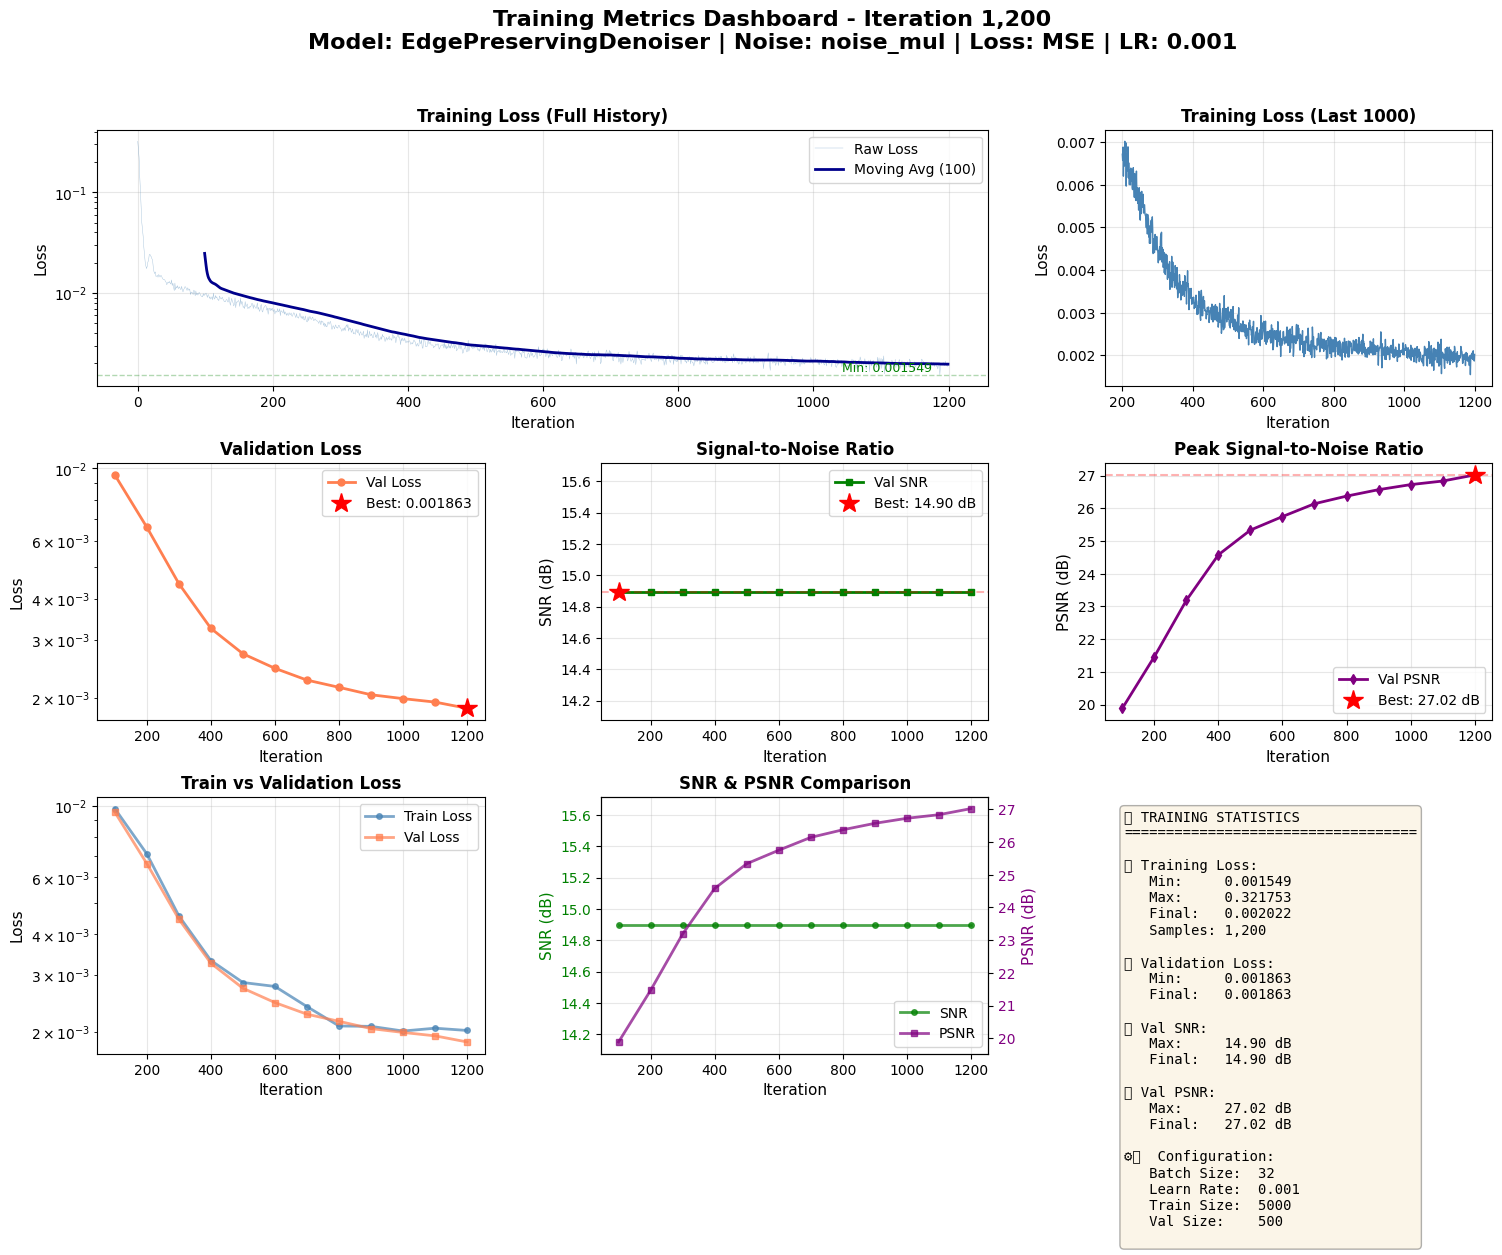


📈 DETAILED TRAINING SUMMARY
Training Loss:
  Min:         0.001549
  Max:         0.321753
  Final:       0.002022
  Mean:        0.005073
  Std:         0.014938
  Samples:     1,200

Validation Loss:
  Min:         0.001863
  Final:       0.001863
  Improvement: 80.49%

Validation SNR:
  Max:         14.90 dB
  Final:       14.90 dB
  Mean:        14.90 dB

Validation PSNR:
  Max:         27.02 dB
  Final:       27.02 dB
  Mean:        24.99 dB



In [8]:
# =============================================================================
# VISUALIZATION & ANALYSIS
# =============================================================================
def plot_training_metrics(checkpoint_dir, save_fig=False):
    """
    Plot comprehensive training metrics from checkpoint data.

    Args:
        checkpoint_dir: Directory containing checkpoints
        save_fig: If True, saves plots to file
    """
    from pathlib import Path

    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    checkpoint = load_checkpoint_generic(checkpoint_dir, device='cpu')

    if checkpoint is None:
        print("❌ No checkpoint found!")
        return

    # Extract data
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    val_snrs = checkpoint.get('val_snrs', [])
    val_psnrs = checkpoint.get('val_psnrs', [])
    config = checkpoint.get('config', {})
    iteration = checkpoint.get('iteration', 0)

    # Calculate validation iteration indices
    val_iters = np.arange(VALIDATION_INTERVAL,
                         VALIDATION_INTERVAL * (len(val_losses) + 1),
                         VALIDATION_INTERVAL)

    # Create figure with better layout
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # Main title
    fig.suptitle(f'Training Metrics Dashboard - Iteration {iteration:,}\n'
                 f'Model: EdgePreservingDenoiser | '
                 f'Noise: {config.get("noise_fn", "N/A")} | '
                 f'Loss: {config.get("loss_fn", "N/A")} | '
                 f'LR: {config.get("learning_rate", "N/A")}',
                 fontsize=16, fontweight='bold', y=0.98)

    # ========== Plot 1: Training Loss (Full) ==========
    ax1 = fig.add_subplot(gs[0, :2])
    if train_losses:
        ax1.plot(train_losses, linewidth=0.3, alpha=0.5, color='steelblue', label='Raw Loss')

        # Moving average for smoother visualization
        window = min(100, len(train_losses) // 10)
        if window > 1:
            train_ma = np.convolve(train_losses, np.ones(window)/window, mode='valid')
            ax1.plot(range(window-1, len(train_losses)), train_ma,
                    linewidth=2, color='darkblue', label=f'Moving Avg ({window})')

        ax1.set_xlabel('Iteration', fontsize=11)
        ax1.set_ylabel('Loss', fontsize=11)
        ax1.set_title('Training Loss (Full History)', fontsize=12, fontweight='bold')
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)
        ax1.set_yscale('log')

        # Add min/max annotations
        min_loss = min(train_losses)
        max_loss = max(train_losses[:100]) if len(train_losses) > 100 else max(train_losses)
        ax1.axhline(y=min_loss, color='green', linestyle='--', alpha=0.3, linewidth=1)
        ax1.text(len(train_losses)*0.98, min_loss, f'Min: {min_loss:.6f}',
                ha='right', va='bottom', fontsize=9, color='green')

    # ========== Plot 2: Training Loss (Recent) ==========
    ax2 = fig.add_subplot(gs[0, 2])
    if train_losses:
        recent_n = min(1000, len(train_losses))
        recent_losses = train_losses[-recent_n:]
        ax2.plot(range(len(train_losses) - recent_n, len(train_losses)),
                recent_losses, linewidth=1, color='steelblue')
        ax2.set_xlabel('Iteration', fontsize=11)
        ax2.set_ylabel('Loss', fontsize=11)
        ax2.set_title(f'Training Loss (Last {recent_n})', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)

    # ========== Plot 3: Validation Loss ==========
    ax3 = fig.add_subplot(gs[1, 0])
    if val_losses:
        ax3.plot(val_iters, val_losses, marker='o', linewidth=2,
                markersize=5, color='coral', label='Val Loss')
        ax3.set_xlabel('Iteration', fontsize=11)
        ax3.set_ylabel('Loss', fontsize=11)
        ax3.set_title('Validation Loss', fontsize=12, fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        ax3.set_yscale('log')

        # Mark best
        min_val_loss = min(val_losses)
        min_idx = val_losses.index(min_val_loss)
        ax3.plot(val_iters[min_idx], min_val_loss, 'r*', markersize=15,
                label=f'Best: {min_val_loss:.6f}')
        ax3.legend()

    # ========== Plot 4: SNR ==========
    ax4 = fig.add_subplot(gs[1, 1])
    if val_snrs:
        ax4.plot(val_iters, val_snrs, marker='s', linewidth=2,
                markersize=5, color='green', label='Val SNR')
        ax4.set_xlabel('Iteration', fontsize=11)
        ax4.set_ylabel('SNR (dB)', fontsize=11)
        ax4.set_title('Signal-to-Noise Ratio', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # Mark best
        max_snr = max(val_snrs)
        max_idx = val_snrs.index(max_snr)
        ax4.axhline(y=max_snr, color='red', linestyle='--', alpha=0.3)
        ax4.plot(val_iters[max_idx], max_snr, 'r*', markersize=15,
                label=f'Best: {max_snr:.2f} dB')
        ax4.legend()

    # ========== Plot 5: PSNR ==========
    ax5 = fig.add_subplot(gs[1, 2])
    if val_psnrs:
        ax5.plot(val_iters, val_psnrs, marker='d', linewidth=2,
                markersize=5, color='purple', label='Val PSNR')
        ax5.set_xlabel('Iteration', fontsize=11)
        ax5.set_ylabel('PSNR (dB)', fontsize=11)
        ax5.set_title('Peak Signal-to-Noise Ratio', fontsize=12, fontweight='bold')
        ax5.legend()
        ax5.grid(True, alpha=0.3)

        # Mark best
        max_psnr = max(val_psnrs)
        max_idx = val_psnrs.index(max_psnr)
        ax5.axhline(y=max_psnr, color='red', linestyle='--', alpha=0.3)
        ax5.plot(val_iters[max_idx], max_psnr, 'r*', markersize=15,
                label=f'Best: {max_psnr:.2f} dB')
        ax5.legend()

    # ========== Plot 6: Loss Comparison ==========
    ax6 = fig.add_subplot(gs[2, 0])
    if train_losses and val_losses:
        # Downsample train losses to match validation intervals
        train_at_val = [train_losses[min(i-1, len(train_losses)-1)] for i in val_iters]
        ax6.plot(val_iters, train_at_val, marker='o', linewidth=2,
                markersize=4, alpha=0.7, label='Train Loss', color='steelblue')
        ax6.plot(val_iters, val_losses, marker='s', linewidth=2,
                markersize=4, alpha=0.7, label='Val Loss', color='coral')
        ax6.set_xlabel('Iteration', fontsize=11)
        ax6.set_ylabel('Loss', fontsize=11)
        ax6.set_title('Train vs Validation Loss', fontsize=12, fontweight='bold')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
        ax6.set_yscale('log')

    # ========== Plot 7: SNR + PSNR Combined ==========
    ax7 = fig.add_subplot(gs[2, 1])
    if val_snrs and val_psnrs:
        ax7_twin = ax7.twinx()

        line1 = ax7.plot(val_iters, val_snrs, marker='o', linewidth=2,
                        markersize=4, color='green', label='SNR', alpha=0.7)
        line2 = ax7_twin.plot(val_iters, val_psnrs, marker='s', linewidth=2,
                             markersize=4, color='purple', label='PSNR', alpha=0.7)

        ax7.set_xlabel('Iteration', fontsize=11)
        ax7.set_ylabel('SNR (dB)', fontsize=11, color='green')
        ax7_twin.set_ylabel('PSNR (dB)', fontsize=11, color='purple')
        ax7.set_title('SNR & PSNR Comparison', fontsize=12, fontweight='bold')
        ax7.tick_params(axis='y', labelcolor='green')
        ax7_twin.tick_params(axis='y', labelcolor='purple')
        ax7.grid(True, alpha=0.3)

        # Combined legend
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax7.legend(lines, labels, loc='lower right')

    # ========== Plot 8: Statistics Summary ==========
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.axis('off')

    stats_text = "📊 TRAINING STATISTICS\n" + "="*35 + "\n\n"

    if train_losses:
        stats_text += f"📈 Training Loss:\n"
        stats_text += f"   Min:     {min(train_losses):.6f}\n"
        stats_text += f"   Max:     {max(train_losses):.6f}\n"
        stats_text += f"   Final:   {train_losses[-1]:.6f}\n"
        stats_text += f"   Samples: {len(train_losses):,}\n\n"

    if val_losses:
        stats_text += f"📉 Validation Loss:\n"
        stats_text += f"   Min:     {min(val_losses):.6f}\n"
        stats_text += f"   Final:   {val_losses[-1]:.6f}\n\n"

    if val_snrs:
        stats_text += f"🔊 Val SNR:\n"
        stats_text += f"   Max:     {max(val_snrs):.2f} dB\n"
        stats_text += f"   Final:   {val_snrs[-1]:.2f} dB\n\n"

    if val_psnrs:
        stats_text += f"📸 Val PSNR:\n"
        stats_text += f"   Max:     {max(val_psnrs):.2f} dB\n"
        stats_text += f"   Final:   {val_psnrs[-1]:.2f} dB\n\n"

    stats_text += f"⚙️  Configuration:\n"
    stats_text += f"   Batch Size:  {config.get('batch_size', 'N/A')}\n"
    stats_text += f"   Learn Rate:  {config.get('learning_rate', 'N/A')}\n"
    stats_text += f"   Train Size:  {config.get('train_size', 'N/A')}\n"
    stats_text += f"   Val Size:    {config.get('val_size', 'N/A')}\n"

    ax8.text(0.05, 0.95, stats_text, transform=ax8.transAxes,
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    if save_fig:
        plot_path = checkpoint_dir / f'training_metrics_iter{iteration}.png'
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"📊 Plot saved to {plot_path}")

    plt.show()

    # Print detailed summary to console
    print("\n" + "=" * 80)
    print("📈 DETAILED TRAINING SUMMARY")
    print("=" * 80)
    if train_losses:
        print(f"Training Loss:")
        print(f"  Min:         {min(train_losses):.6f}")
        print(f"  Max:         {max(train_losses):.6f}")
        print(f"  Final:       {train_losses[-1]:.6f}")
        print(f"  Mean:        {np.mean(train_losses):.6f}")
        print(f"  Std:         {np.std(train_losses):.6f}")
        print(f"  Samples:     {len(train_losses):,}")
        print()

    if val_losses:
        print(f"Validation Loss:")
        print(f"  Min:         {min(val_losses):.6f}")
        print(f"  Final:       {val_losses[-1]:.6f}")
        print(f"  Improvement: {((val_losses[0] - val_losses[-1]) / val_losses[0] * 100):.2f}%")
        print()

    if val_snrs:
        print(f"Validation SNR:")
        print(f"  Max:         {max(val_snrs):.2f} dB")
        print(f"  Final:       {val_snrs[-1]:.2f} dB")
        print(f"  Mean:        {np.mean(val_snrs):.2f} dB")
        print()

    if val_psnrs:
        print(f"Validation PSNR:")
        print(f"  Max:         {max(val_psnrs):.2f} dB")
        print(f"  Final:       {val_psnrs[-1]:.2f} dB")
        print(f"  Mean:        {np.mean(val_psnrs):.2f} dB")
        print()

    print("=" * 80)


# Plot the metrics
plot_training_metrics(CHECKPOINT_DIR, save_fig=True)
